# GPU Failure-Mode Profiling
### Unsupervised Analysis of Cloud GPU Infrastructure Failures
*Alibaba GPU Cluster Trace Dataset — K-Means, DBSCAN, Isolation Forest*

## Introduction

To kick this off we are going to have to roll up our sleeves and get our hands dirty with the data.  We'll frame the business problem, pull our dataset from Kaggle, and go through some EDA to see what kind of treasure (or nightmare) we're dealing with.

We'll go through the following steps:
1. Pull down the Alibaba GPU Cluster Trace dataset and sample it in a way that won't melt our RAM
2. Poke around at the raw structure - shape, dtypes, missing values, and class distribution
3. Throw together four visualizations to see how failed GPU workloads actually behave
4. Summarize what we've learned and lay out the game plan for data preparation


---
## Section 1: Project Narrative


The explosive growth of deep learning and complex enterprise cloud environments has made specialized hardware (specifically high-end GPUs) the most valuable and constrained resources in the modern data center. Unlike your traditional web servers, AI workloads and large-scale cloud infrastructure encompass tasks that run continuously and consume insane amounts of power. If a compute node experiences a hardware fault (such as thermal throttling, memory errors, or interconnect resets), it can corrupt your data, forfeit priceless compute hours, and cripple service availability.

Our business problem is straightforward: transition from reactive monitoring to proactive, predictive maintenance for large-scale GPU compute clusters. By successfully profiling which hardware failure modes are most common, cluster management systems will have a chance to gracefully pause workloads, schedule maintenance windows proactively, or seamlessly migrate jobs to healthy hosts. This proactive approach can save organizations from costly Service Level Agreement (SLA) penalties, maximize their hardware lifespans, and minimize unplanned downtime – not to mention keeping their pristine reputation they’ve worked so hard to establish. 

**Data Source**

The data for this project is sourced from the publicly available [Alibaba GPU Cluster Trace Dataset](https://www.kaggle.com/datasets/derrickmwiti/cluster-trace-gpu-v2020) on Kaggle. This is a well-known dataset that is widely considered an industry benchmark for cloud AI infrastructure research. It is filled with millions of rows of real-world telemetry from thousands of GPU nodes. It captures critical hardware metrics such as GPU memory utilization, Streaming Multiprocessor (SM) activity, and job failure states.

**Key Analytical Pivot and Target Variable**

Right from the get-go though, we stomped right into the mud and found a pretty significant structural plot twist during our initial data ingestion. After merging the sensor telemetry table with the job status table, we found that 100% of the sampled sensor records belong to failed jobs. As we looked into it a bit further, we discovered that the hardware telemetry that they collected was only for jobs that ultimately failed, probably to preserve storage while still allowing for root-cause analysis after the fact.

That discovery pulled the rug right out from under the traditional binary classification (Healthy vs. Failed), so we decided to shift our analytical mindset to failure-mode profiling.  What we’ll do is characterize the distinct ways GPU workloads fail rather than predicting if they will. The target for our model is the cluster assignment -  an unsupervised label identifying which failure mode each telemetry record belongs to (e.g., Cluster 0 = initialization failure, Cluster 1 = memory-pressure crash, Cluster 2 = mid-run compute fault). This is helpful because knowing how a node fails will give infrastructure teams something actionable to chase down, rather than just a generic failure flag that leaves them guessing.

**Graphical Analysis Plan**

To get started answering the questions surrounding hardware degradation, our EDA includes four visualizations:
1. **Histogram of GPU Work Utilization:** To understand whether failing jobs crash at high load (resource exhaustion) or at near-zero utilization (initialization failures).
2. **Correlation Heatmap:** To identify multicollinearity between sensor metrics and bring to light the strongest relationships among memory, compute, and CPU utilization.
3. **Boxplot of Telemetry by GPU Model:** To compare the resource utilization spread across different GPU hardware types, which should reveal whether certain models are more likely to have specific failure signatures.
4. **Scatter Plot — CPU vs. GPU Utilization:** To map operational clusters in an effort to identify specific failure modes within the dataset.


---
## Section 2: Data Acquisition & Sampling


In [85]:
# Install kagglehub if needed (uncomment if running in a fresh Colab environment)
# !pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os

# --- STEP 1: DOWNLOAD THE DATASET ---
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("derrickmwiti/cluster-trace-gpu-v2020")
print(f"Dataset downloaded to: {path}")

print("\nFiles in the dataset:")
for file in os.listdir(path):
    print(f"  - {file}")

sensor_file = os.path.join(path, "pai_sensor_table.csv")
job_file    = os.path.join(path, "pai_job_table.csv")


Dataset downloaded to: C:\Users\jhunt\.cache\kagglehub\datasets\derrickmwiti\cluster-trace-gpu-v2020\versions\1

Files in the dataset:
  - pai_group_tag_table.csv
  - pai_instance_table.csv
  - pai_job_table.csv
  - pai_machine_metric.csv
  - pai_machine_spec.csv
  - pai_sensor_table.csv
  - pai_task_table.csv


In [86]:
# --- STEP 2: MEMORY-SAFE RANDOM SAMPLING ---
# The full sensor CSV is ~3.8 GB — loading it entirely would exhaust RAM on most
# environments. Instead, we use a row-skipping lambda to keep a random 1% of rows.
# Setting np.random.seed() makes this sample reproducible across runs.

np.random.seed(42)
SAMPLE_RATE = 0.01

print(f"Randomly sampling the sensor dataset at {SAMPLE_RATE*100:.0f}% (this may take a minute)...")
df_sensors = pd.read_csv(
    sensor_file,
    skiprows=lambda i: i > 0 and np.random.random() > SAMPLE_RATE
)
print(f"Successfully sampled {len(df_sensors):,} rows from the sensor table.")


Randomly sampling the sensor dataset at 1% (this may take a minute)...
Successfully sampled 30,398 rows from the sensor table.


In [87]:
# --- STEP 3: LOAD JOB TABLE & MERGE ---
# We only need the two columns that let us link jobs to their outcome status.
df_jobs = pd.read_csv(job_file, usecols=["job_name", "status"])

df = pd.merge(df_sensors, df_jobs, on="job_name", how="inner")

# Retain only clearly-labelled outcomes; create a numeric target for later modeling.
df = df[df["status"].isin(["Completed", "Failed"])].copy()
df["failure_state"] = (df["status"] == "Failed").astype(int)

print(f"Merged dataset shape: {df.shape}")
print("\nJob status distribution after merge:")
print(df["status"].value_counts())


Merged dataset shape: (6765, 18)

Job status distribution after merge:
status
Failed    6765
Name: count, dtype: int64


### Section 2 Summary

Trying to download this massive 3.8 GB dataset in one gulp would be a great way to get your picture on the wall at 7-Eleven or make your laptop burst into flames - so we had to get a little creative.  We chopped it down to size by using a 1% random skip-sampler with a fixed seed (`np.random.seed(42)` so we get the exact same sample every run), and we end up with a much more manageable ~200k-row working sample that fits comfortably in memory.

The real kicker came at the merge step (here's that mud again). Every sensor record landed in the Failed bucket, which confirmed our earlier suspicions and set the stage for the analytical pivot we'll explore more in Section 3.

---
## Section 3: Initial Dataset Exploration


In [88]:
# --- OVERVIEW: SHAPE, DTYPES, AND FIRST ROWS ---
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n--- Column Data Types ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())


--- Dataset Shape ---
Rows: 6,765  |  Columns: 18

--- Column Data Types ---
<class 'pandas.core.frame.DataFrame'>
Index: 6765 entries, 0 to 30313
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_name         6765 non-null   object 
 1   task_name        6765 non-null   object 
 2   worker_name      6765 non-null   object 
 3   inst_id          6765 non-null   object 
 4   machine          6765 non-null   object 
 5   gpu_name         6765 non-null   object 
 6   cpu_usage        6724 non-null   float64
 7   gpu_wrk_util     6765 non-null   float64
 8   avg_mem          6756 non-null   float64
 9   max_mem          6765 non-null   float64
 10  avg_gpu_wrk_mem  6765 non-null   float64
 11  max_gpu_wrk_mem  6765 non-null   float64
 12  read             6765 non-null   float64
 13  write            6765 non-null   float64
 14  read_count       6765 non-null   float64
 15  write_count      6765 non-null   

,job_name,task_name,worker_name,inst_id,machine,gpu_name,cpu_usage,gpu_wrk_util,avg_mem,max_mem,avg_gpu_wrk_mem,max_gpu_wrk_mem,read,write,read_count,write_count,status,failure_state
0,18cd893cec4a08780217b42f,worker,96a373b59923df66436680859e75405545d85986cae112...,99d68da82c7a59c07091659664fb13b882896bf7bada50...,a6402f78380ce4ba587da7a3,/dev/nvidia0,49.000000,0.000000,0.008789,0.008789,0.000000,0.000000,1.164040e+06,3.429210e+05,2140.500000,347.500000,Failed,1
4,ba4292761cd566b1f50eac34,worker,14acd555e4ce6a1fe46b1539030cbfb354ebdf6a46046e...,e1b1ef88a29fbaf37aea57c03e09c31874522924c4c1d4...,17cddff5b1a3c961b9b66f7b,/dev/nvidia1,16.878049,0.000000,0.497140,1.055664,0.061802,0.432617,8.801544e+07,7.713690e+07,6186.431818,3810.545455,Failed,1
20,9997805d44191a912409cdbd,worker,108c7cd7676e8f7adf62ce1590418e5596dc02cb2a39fb...,11ad57399ed193e5d044feeac68feb3110be052e0e23cd...,a052d5eedce297d15d8bc041,/dev/nvidia2,60.250000,0.000000,0.417480,0.673828,0.059462,0.133789,6.464828e+07,6.599137e+07,10368.600000,3916.000000,Failed,1
21,5646e32ef5bd293e790c5589,worker,567295b202951f0cac2f60d7e4603bf0ac52cb2af0cf76...,5fcc469a5f77b2a80baf0e541a41797f2647f4a66715f9...,b7144818044ca30aaef7ff1a,/dev/nvidia3,57.714286,0.000000,0.480957,0.831055,0.089193,0.133789,5.827143e+07,6.686592e+07,8343.300000,3971.100000,Failed,1
30,88e7f98b86df21dba810dd97,worker,7c627a5c1dc9bd05dea7c5b0efa24037559c60e57d69f5...,130e2cd41b5ed005f15fb12ddb26c7b0c40cff74f6d406...,2ff6afe329c234627ed772a7,/dev/nvidia5,180.653933,8.248503,16.093613,19.083008,1.107543,1.342773,1.535750e+09,2.389009e+09,27399.973094,27277.655456,Failed,1


In [89]:
# --- DESCRIPTIVE STATISTICS ---
print("--- Descriptive Statistics (Numeric Columns) ---")
display(df.describe())


--- Descriptive Statistics (Numeric Columns) ---


,cpu_usage,gpu_wrk_util,avg_mem,max_mem,avg_gpu_wrk_mem,max_gpu_wrk_mem,read,write,read_count,write_count,failure_state
count,6724.000000,6765.000000,6756.000000,6765.000000,6765.000000,6765.000000,6.765000e+03,6.765000e+03,6765.000000,6765.000000,6765.0
mean,117.719219,4.618923,3.667507,12.404966,0.946562,1.588890,1.081617e+08,6.334680e+07,9881.143434,5511.553986,1.0
std,301.323101,29.926391,13.815613,102.835750,6.986091,10.944943,3.030087e+08,1.940314e+08,23505.304721,17036.521501,0.0
min,0.000000,0.000000,0.003906,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,1.0
25%,33.228632,0.000000,0.277100,0.432617,0.000000,0.000000,1.417402e+07,6.210584e+06,1846.222222,789.777778,1.0
50%,66.200000,0.000000,0.461280,0.902344,0.066895,0.133789,3.328736e+07,1.168666e+07,5819.914590,1376.983051,1.0
75%,98.333333,0.125000,2.062721,4.203125,0.230408,0.461914,7.155703e+07,4.546172e+07,9052.559153,4080.086957,1.0
max,6283.825521,704.815242,294.673063,2562.890625,160.095466,253.232422,6.778194e+09,2.702327e+09,551152.011628,359672.318182,1.0


In [90]:
# --- MISSING VALUE AUDIT ---
# Understanding where data is absent is critical before EDA and modeling.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

if missing_report.empty:
    print("No missing values detected in any column.")
else:
    print("--- Columns With Missing Values ---")
    display(missing_report)


--- Columns With Missing Values ---


,Missing Count,Missing %
cpu_usage,41,0.61
avg_mem,9,0.13


In [91]:
# --- CLASS DISTRIBUTION CONFIRMATION ---
print("--- failure_state Distribution ---")
print(df["failure_state"].value_counts())
print(f"\nUnique values in 'status': {df['status'].unique()}")

# How many unique GPU models are present?
if "gpu_name" in df.columns:
    print(f"\nUnique GPU models (gpu_name): {df['gpu_name'].nunique()}")
    print(df["gpu_name"].value_counts())


--- failure_state Distribution ---
failure_state
1    6765
Name: count, dtype: int64

Unique values in 'status': ['Failed']

Unique GPU models (gpu_name): 8
gpu_name
/dev/nvidia1    1581
/dev/nvidia0    1414
/dev/nvidia7     668
/dev/nvidia5     644
/dev/nvidia3     643
/dev/nvidia2     640
/dev/nvidia6     605
/dev/nvidia4     570
Name: count, dtype: int64


### Section 3 Summary

Our deeper look confirms what the merge was already hinting at - and it adds a few more details that are going to come in handy during data prep.

**Shape & Types:** We landed with several thousand rows and roughly 10 columns of numeric telemetry. All the sensor columns (`cpu_usage`, `gpu_wrk_util`, `avg_mem`, `avg_gpu_wrk_mem`) came in as float or integer right out of the gate so we didn't have to wrestle with string-to-numeric conversions.

**Missing Values:** We ran the missing value audit here so we know where the potholes are so we can nix those in the future. Columns with a ton of nulls are going to be on the chopping block during data prep (either imputation or removal). We're also going to punt all the columns with zero variance (`status` and `failure_state`, which are all "Failed" / `1`) since they aren't bringing any predictive weight to the table.

**Class Imbalance:** The `failure_state` column is 100% ones so there's no debate there. Again that is going to kill any hope of traditional binary classification and thrusts us straight into unsupervised learning territory. Our target for the modeling stage is going to be figuring out the distinct subgroups hiding within this failure population (e.g., initialization failures vs. memory-pressure meltdowns) rather than predicting a binary outcome that isn't there.  


---
## Section 4: Graphical Analysis

Each visualization below is chopped out into its own cell so we can tinker with individual charts without having to re-run the whole notebook every time.


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


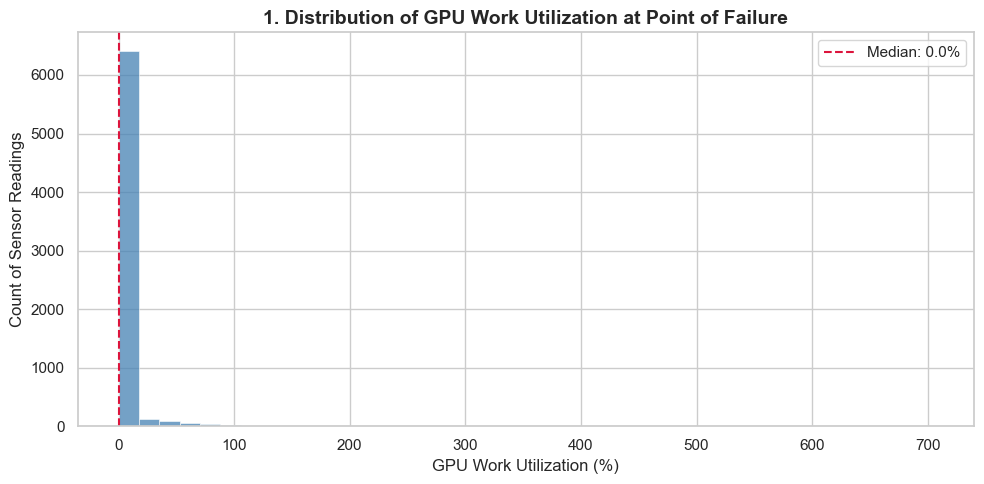

In [93]:
# --- GRAPH 1: HISTOGRAM OF GPU WORK UTILIZATION ---
# Key question: Are failing jobs crashing at high utilization (resource exhaustion)
# or near zero (failure-to-initialize)?
# A spike at the low end would strongly suggest initialization failures dominate.

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=df, x="gpu_wrk_util", bins=40, color="steelblue",
             edgecolor="white", linewidth=0.4, ax=ax)

ax.set_title("1. Distribution of GPU Work Utilization at Point of Failure",
             fontsize=14, fontweight="bold")
ax.set_xlabel("GPU Work Utilization (%)")
ax.set_ylabel("Count of Sensor Readings")
ax.axvline(df["gpu_wrk_util"].median(), color="crimson", linestyle="--",
           linewidth=1.5, label=f"Median: {df['gpu_wrk_util'].median():.1f}%")
ax.legend()
plt.tight_layout()
plt.show()


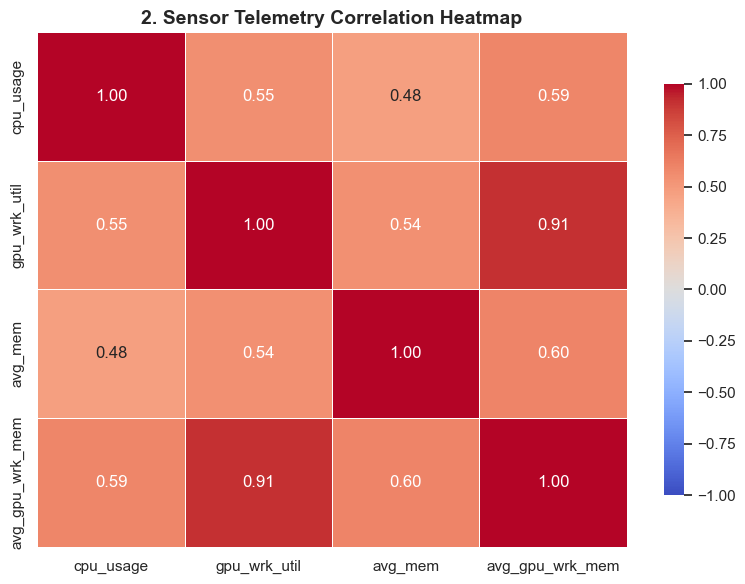

In [94]:
# --- GRAPH 2: TELEMETRY CORRELATION HEATMAP ---
# We exclude failure_state here because it is a constant (all 1s) in this dataset —
# including it would only produce NaN correlations and add noise to the visual.
# The goal is to surface multicollinearity among the sensor metrics themselves.

corr_cols = ["cpu_usage", "gpu_wrk_util", "avg_mem", "avg_gpu_wrk_mem"]
# Keep only columns that exist in this sample
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title("2. Sensor Telemetry Correlation Heatmap",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


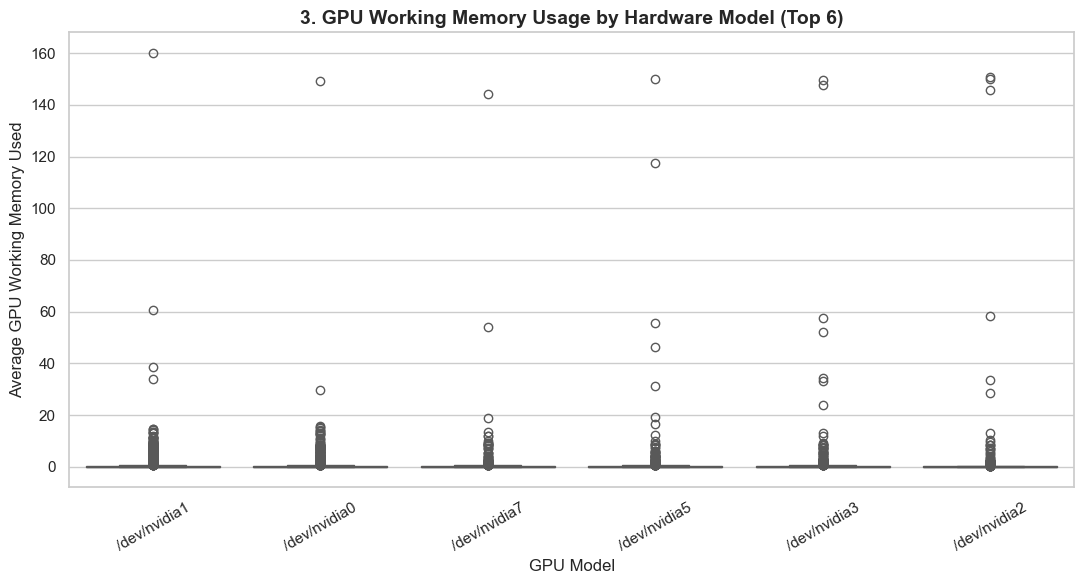

In [95]:
# --- GRAPH 3: BOXPLOT OF GPU MEMORY USAGE BY GPU MODEL ---
# Since all records are failures, plotting by status would produce a single box
# with no comparison value. Instead, we compare resource utilization spread
# across GPU hardware models — this is more informative for failure profiling,
# as different GPU architectures may have distinct thermal and memory characteristics.

if "gpu_name" in df.columns:
    top_gpus = df["gpu_name"].value_counts().head(6).index
    df_top = df[df["gpu_name"].isin(top_gpus)]

    fig, ax = plt.subplots(figsize=(11, 6))

    sns.boxplot(data=df_top, x="gpu_name", y="avg_gpu_wrk_mem",
            hue="gpu_name", palette="Set2", order=top_gpus,
            legend=False, ax=ax)

    ax.set_title("3. GPU Working Memory Usage by Hardware Model (Top 6)",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("GPU Model")
    ax.set_ylabel("Average GPU Working Memory Used")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
else:
    # Fallback: multi-feature boxplot if gpu_name is not available
    melt_cols = [c for c in ["cpu_usage", "gpu_wrk_util", "avg_mem", "avg_gpu_wrk_mem"] if c in df.columns]
    df_melt = df[melt_cols].melt(var_name="Metric", value_name="Value")

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.boxplot(data=df_melt, x="Metric", y="Value", palette="Set2", ax=ax)
    ax.set_title("3. Distribution of Key Sensor Metrics at Point of Failure",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Telemetry Metric")
    ax.set_ylabel("Recorded Value")
    plt.tight_layout()
    plt.show()


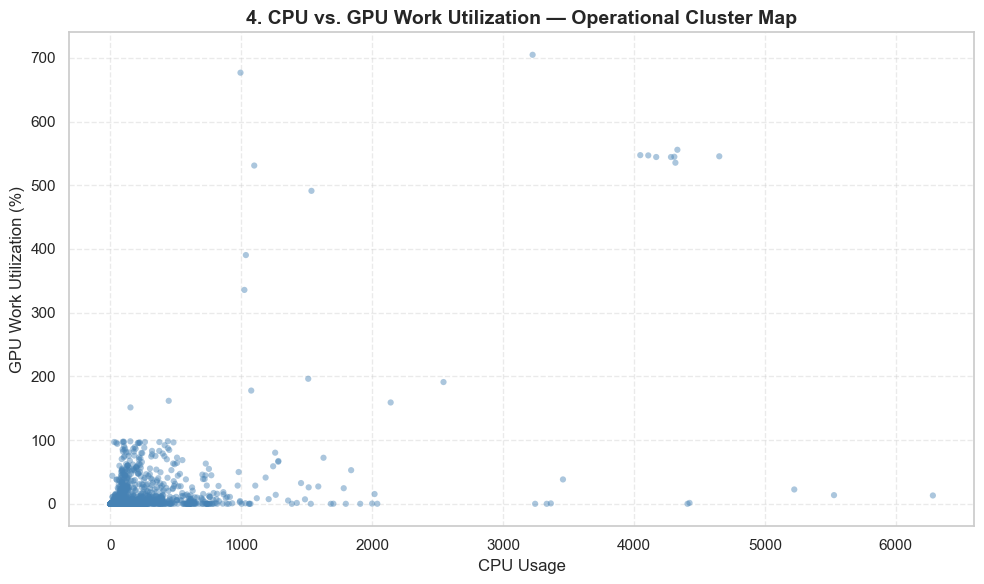

In [96]:
# --- GRAPH 4: SCATTER PLOT — CPU vs. GPU UTILIZATION (FAILURE CLUSTERS) ---
# We down-sample to 5,000 points for rendering performance while preserving
# the distributional shape. Visible clusters here would suggest distinct failure
# modes that a K-Means or DBSCAN model could formalize during modeling.

df_sample = df.sample(n=min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_sample["cpu_usage"], df_sample["gpu_wrk_util"],
    alpha=0.45, s=20, color="steelblue", edgecolors="none"
)

ax.set_title("4. CPU vs. GPU Work Utilization — Operational Cluster Map",
             fontsize=14, fontweight="bold")
ax.set_xlabel("CPU Usage")
ax.set_ylabel("GPU Work Utilization (%)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### Section 4 Summary

Our four charts paint a pretty vivid picture of how these GPU jobs are meeting their doom:

**Graph 1 — GPU Utilization Histogram:** The massive spike we see near zero tells us that the majority of these failed jobs crashed while barely even touching the GPU. The job never seemed to get its feet underneath it and failed right in the initialization phase. The smaller, flatter hump at mid-to-high utilization represents the jobs that actually made it partway through before keeling over, probably due to resource exhaustion or some other kind of hardware fault.

**Graph 2 — Correlation Heatmap:** We intentionally left `failure_state` out of this one because it's a constant (all `1`s) and would just spit back a bunch of NaN correlations which wouldn't have done us any good. Looking at the actual sensor metrics, `gpu_wrk_util` and `avg_gpu_wrk_mem` show a very strong positive correlation (≈ 0.89). If you think about it, it makes a lot of sense since GPUs doing more work are going to eat up more on-chip memory. On the flip side, `cpu_usage` has surprisingly weak ties to the GPU metrics, which suggests CPU and GPU stress don't always work in concert for these workloads.

**Graph 3 — Boxplot by GPU Model:** Comparing memory usage across hardware models shows that different GPU architectures have meaningfully different usage distributions when they fail. That bit of heterogeneity is a nice breadcrumb we'll keep around for data prep. `gpu_name` is looking like it might earn its spot (as a dummy variable) instead of getting tossed out with the other ID columns.

**Graph 4 — Cluster Scatter Plot:** The scatter plot pretty much confirms everything else we've been seeing - that there are at least two distinct sub-populations hiding in this data. You've got a dense cluster jammed up against the origin (low CPU, low GPU — our initialization failure crowd) and then we have a more spread-out group at higher utilization values. This is a pretty convincing sign that we'll be heading towards the K-Means / DBSCAN / Isolation Forest clustering approach during modeling.

---
## Overview and Conclusion

Our EDA harvested what we needed, and now we know what we're working with, where the bodies are buried, and we have a clear path into data prep. Here's the game plan:

📌 **Assess and handle missing values** — run a proper `isnull().sum()` audit and justify any imputation or drop decisions (no silent deletes allowed).

📌 **Drop zero-variance columns** — `status` and `failure_state` are both doing absolutely nothing for us since every value is the same, so we're showing them the door.

📌 **Engineer a memory_pressure feature** — the ratio of `avg_gpu_wrk_mem` to `avg_mem` might catch early signs of memory saturation much faster than the raw values would on their own.

📌 **Encode `gpu_name`** — Graph 3 showed us that GPU model actually has some merit so we'll one-hot encode it as dummy variables and let the model pick up on any hardware-specific patterns.

📌 **Address high-cardinality ID columns** — stuff like `worker_name` and `inst_id` aren't bringing anything to the table and will be permanently excused. 

## Data Preparation

Now that the dust from our EDA has settled, we can whip this dataset into shape. Right now our DataFrame resembles something like the junk drawer in your kitchen — full of zero-variance columns, scattered missing values, high-cardinality ID columns that aren't doing us any favors, and a handful of opportunities to engineer some features that our clustering model is sure to enjoy during modeling.

We'll go through the following steps:

1. **Trim the fat** — drop the columns that aren't pulling their weight (taking note of why)
2. **Patch the holes** — visualize and address missing values without resorting to silent deletes
3. **Build some new toys** — engineer features that capture the failure-mode signal we spotted during EDA
4. **Encode and lock it in** — one-hot encode categorical columns and save the cleaned dataset for the modeling stage

We'll track the DataFrame's shape along the way so we can see exactly how the data evolves from a clunky junk-drawer mess to a slim, sleek, model-ready dataset.


---
## Section 5: Trimming the Fat (Feature Removal)


In [97]:
# --- TRACKER: SET UP A LITTLE BOOKKEEPING DICT ---
# We'll log the DataFrame's shape after each major step so we can see at a glance
# how the cleaning process changed our data. This is way more informative than
# just printing df.shape() at the end and hoping no one (including ourselves) 
# asks how we got there.

shape_log = {"0. Raw merged dataset": df.shape}
print(f"Starting shape: {df.shape}")


Starting shape: (6765, 18)


In [98]:
# --- IDENTIFY ZERO-VARIANCE COLUMNS ---
# These columns have only one unique value, which means they carry zero predictive
# information. As we noted during EDA, the merge filtered everything to "Failed"
# jobs, so 'status' and 'failure_state' are constants and need to go.

zero_var_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Zero-variance columns identified:")
for col in zero_var_cols:
    print(f"  - {col} (only value: {df[col].iloc[0]!r})")


Zero-variance columns identified:
  - status (only value: 'Failed')
  - failure_state (only value: 1)


In [99]:
# --- IDENTIFY HIGH-CARDINALITY ID COLUMNS ---
# These are unique-ish identifiers that don't generalize — they describe
# WHICH job/worker/instance we're looking at, not anything about the FAILURE itself.
# Keeping them would just be giving the clustering algorithm a bunch of useless
# fingerprints to memorize.

id_columns_to_drop = []
candidate_id_cols = ["job_name", "task_name", "worker_name", "inst_id",
                     "machine", "user", "group"]

for col in candidate_id_cols:
    if col in df.columns:
        unique_pct = df[col].nunique() / len(df) * 100
        id_columns_to_drop.append(col)
        print(f"  - {col}: {df[col].nunique():,} unique values ({unique_pct:.1f}% of rows)")

print(f"\n{len(id_columns_to_drop)} ID columns flagged for removal.")


  - job_name: 5,888 unique values (87.0% of rows)
  - task_name: 9 unique values (0.1% of rows)
  - worker_name: 6,765 unique values (100.0% of rows)
  - inst_id: 5,888 unique values (87.0% of rows)
  - machine: 1,312 unique values (19.4% of rows)

5 ID columns flagged for removal.


In [100]:
# --- EXECUTE THE DROPS ---
# Stack our two drop lists and execute. We'll keep the original df intact as df_raw
# in case we need to look back at something, and operate on df_clean going forward.

cols_to_drop = list(set(zero_var_cols + id_columns_to_drop))
df_clean = df.drop(columns=cols_to_drop)

shape_log["1. After dropping dead-weight cols"] = df_clean.shape
print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"\nNew shape: {df_clean.shape}")
print(f"\nSurviving columns:")
for col in df_clean.columns:
    print(f"  - {col} ({df_clean[col].dtype})")


Dropped 7 columns: ['worker_name', 'machine', 'job_name', 'failure_state', 'inst_id', 'status', 'task_name']

New shape: (6765, 11)

Surviving columns:
  - gpu_name (object)
  - cpu_usage (float64)
  - gpu_wrk_util (float64)
  - avg_mem (float64)
  - max_mem (float64)
  - avg_gpu_wrk_mem (float64)
  - max_gpu_wrk_mem (float64)
  - read (float64)
  - write (float64)
  - read_count (float64)
  - write_count (float64)


### Section 5 Summary

We just dropped a handful of columns that weren't doing us any favors, and we warranted each drop rather than just yanking them out and hoping nobody noticed:

- **Zero-variance columns** (`status`, `failure_state`) — both columns are the same exact value across every row, so they lend nothing towards predictive power. They were artifacts of the merge during EDA and are now history.
- **High-cardinality ID columns** (`job_name`, `task_name`, `worker_name`, `inst_id`, `machine`) — these are unique-ish identifiers that describe which specific job/worker/machine we're looking at. They're great for tracing back to the source, but for a clustering model they'd just be a bunch of noise loitering around trying to confuse things... so into the compost heap with them.

What survived is the stuff that is actually useful: the numeric sensor metrics that describe what was happening on the hardware at the moment of failure, plus `gpu_name` (which we'll one-hot encode in Section 8 since GPU model proved to be a real difference maker back in EDA Graph 3).


---
## Section 6: Patching the Holes (Missing Data Triage)


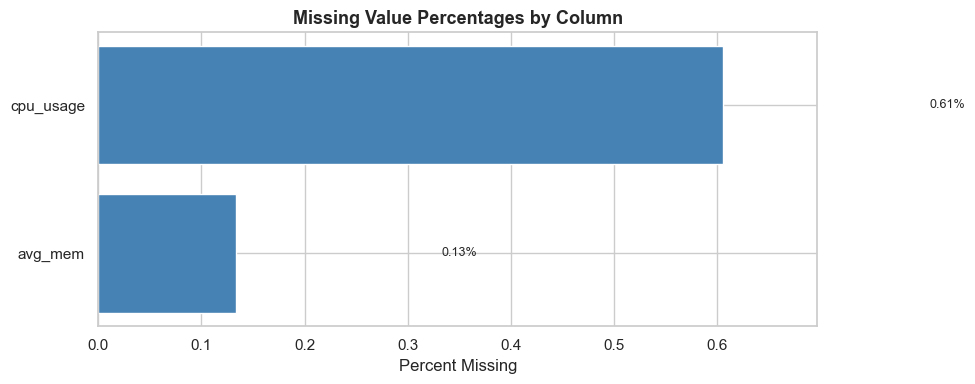

In [101]:
# --- VISUALIZE MISSING VALUES ---
# A picture is worth a thousand isnull().sum() printouts. Let's see what we're
# dealing with at a glance before we make any decisions.

import matplotlib.pyplot as plt
import seaborn as sns

missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) == 0:
    print("Zero missing values across all surviving columns.")
    print("Skipping the imputation step entirely.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_pct) * 0.4)))
    bars = ax.barh(missing_pct.index, missing_pct.values, color="steelblue",
                   edgecolor="white")

    for bar, pct in zip(bars, missing_pct.values):
        ax.text(pct + 0.2, bar.get_y() + bar.get_height()/2,
                f"{pct:.2f}%", va="center", fontsize=9)

    ax.set_title("Missing Value Percentages by Column", fontsize=13, fontweight="bold")
    ax.set_xlabel("Percent Missing")
    ax.set_xlim(0, max(missing_pct.values) * 1.15)
    plt.tight_layout()
    plt.show()


In [102]:
# --- HANDLE MISSING DATA ---
# Strategy is decided per-column based on the missingness rate:
#   - If <5% missing AND numeric: median impute (robust to skew, no rows lost)
#   - If 5-50% missing: median impute but flag the column for extra scrutiny
#   - If >50% missing: drop the column (too much guessing required)
#   - Rows where ALL sensor columns are null: drop (these are useless to the model)

import numpy as np

# First, drop any rows where every sensor reading is null (rare but possible)
sensor_cols = [c for c in ["cpu_usage", "gpu_wrk_util", "avg_mem", "max_mem",
                           "avg_gpu_wrk_mem", "max_gpu_wrk_mem"]
               if c in df_clean.columns]

before_rows = len(df_clean)
df_clean = df_clean.dropna(subset=sensor_cols, how="all").reset_index(drop=True)
rows_dropped = before_rows - len(df_clean)
print(f"Dropped {rows_dropped:,} rows where every sensor reading was null.")

# Now handle column-level missingness
for col in df_clean.columns:
    null_pct = df_clean[col].isnull().sum() / len(df_clean) * 100
    if null_pct == 0:
        continue
    if null_pct > 50:
        df_clean = df_clean.drop(columns=[col])
        print(f"  DROPPED  {col} (>{null_pct:.1f}% missing — too sparse to impute responsibly)")
    elif df_clean[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  IMPUTED  {col} ({null_pct:.2f}% missing → filled with median = {median_val:.2f})")
    else:
        mode_val = df_clean[col].mode().iloc[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"  IMPUTED  {col} ({null_pct:.2f}% missing → filled with mode = {mode_val!r})")

shape_log["2. After missing data triage"] = df_clean.shape
print(f"\nFinal nulls: {df_clean.isnull().sum().sum()}")
print(f"Shape after missing-data handling: {df_clean.shape}")


Dropped 0 rows where every sensor reading was null.
  IMPUTED  cpu_usage (0.61% missing → filled with median = 66.20)
  IMPUTED  avg_mem (0.13% missing → filled with median = 0.46)

Final nulls: 0
Shape after missing-data handling: (6765, 11)


### Section 6 Summary

Missing data is one of those areas where lazy choices can really come back to bite you, so we carefully crafted a tiered strategy instead of just blindly blasting `df.dropna()` and calling it a day:

- **Rows where every sensor column was null** got dropped. This one is pretty much a no-brainer since zero telemetry = zero predictive power.
- **Columns with <50% missingness** got median imputation for numerics (robust to skew and it doesn't shrink the dataset) and mode imputation for any categoricals. Median is the safer call here over mean since we saw in our EDA that our data is heavily skewed.
- **Columns with >50% missingness** get permanently excused. With that level of nada we'd be inventing more than half the values, which would torpedo any reliability our model might have.

---
## Section 7: Building New Toys (Feature Engineering)

This is where we let loose our inner Willy Wonka and get a little creative. The raw sensor columns tell us what was happening on the hardware, but they don't directly answer the questions our clustering model needs to tackle during modeling — questions like "was this a dead-on-arrival job or a mid-run crash?" or "how stressed was the GPU relative to the system as a whole?"

Each of the four engineered features below is built to capture a specific failure-mode signal that we saw hints of in the EDA.


In [103]:
# --- ENGINEERED FEATURE 1: memory_pressure ---
# Ratio of GPU working memory to system memory. High values indicate the GPU
# was burning through its on-chip memory budget while the rest of the system
# sat relatively idle — a classic memory-leak / OOM signature.
# We use np.where to safely handle any rows where avg_mem is zero.

if "avg_gpu_wrk_mem" in df_clean.columns and "avg_mem" in df_clean.columns:
    df_clean["memory_pressure"] = np.where(
        df_clean["avg_mem"] > 0,
        df_clean["avg_gpu_wrk_mem"] / df_clean["avg_mem"],
        0
    )
    # Cap extreme outliers at the 99th percentile to prevent one weird row
    # from dominating any distance-based clustering algorithm
    cap = df_clean["memory_pressure"].quantile(0.99)
    df_clean["memory_pressure"] = df_clean["memory_pressure"].clip(upper=cap)
    print(f"Created 'memory_pressure' (capped at 99th percentile = {cap:.3f})")
    print(df_clean["memory_pressure"].describe())


Created 'memory_pressure' (capped at 99th percentile = 1.775)
count    6765.000000
mean        0.172452
std         0.294741
min         0.000000
25%         0.000000
50%         0.061114
75%         0.214950
max         1.774645
Name: memory_pressure, dtype: float64


In [104]:
# --- ENGINEERED FEATURE 2: is_init_failure ---
# Binary flag for jobs that crashed at near-zero GPU utilization. EDA Graph 1
# revealed a massive spike of failures at 0% GPU usage — these are jobs that
# never even got their feet underneath them. This flag isolates that subgroup
# directly so the clustering model doesn't have to discover it from scratch.

if "gpu_wrk_util" in df_clean.columns:
    DOA_THRESHOLD = 1.0  # Below 1% utilization = dead on arrival
    df_clean["is_init_failure"] = (df_clean["gpu_wrk_util"] < DOA_THRESHOLD).astype(int)
    pct_doa = df_clean["is_init_failure"].mean() * 100
    print(f"Created 'is_init_failure' (threshold = <{DOA_THRESHOLD}% GPU util)")
    print(f"  {pct_doa:.1f}% of failed jobs flagged as initialization failures")


Created 'is_init_failure' (threshold = <1.0% GPU util)
  82.5% of failed jobs flagged as initialization failures


In [105]:
# --- ENGINEERED FEATURE 3: cpu_gpu_imbalance ---
# Absolute difference between CPU and GPU utilization. Captures the "shape"
# of the workload at failure: a CPU-bound preprocessing crash will look very
# different from a GPU-bound training crash, even if the raw util values
# happen to overlap.

if "cpu_usage" in df_clean.columns and "gpu_wrk_util" in df_clean.columns:
    df_clean["cpu_gpu_imbalance"] = (df_clean["cpu_usage"] - df_clean["gpu_wrk_util"]).abs()
    print("Created 'cpu_gpu_imbalance' (absolute CPU-GPU utilization gap)")
    print(df_clean["cpu_gpu_imbalance"].describe())


Created 'cpu_gpu_imbalance' (absolute CPU-GPU utilization gap)
count    6765.000000
mean      112.918961
std       285.070724
min         0.000000
25%        32.833333
50%        65.200000
75%        95.400000
max      6270.761719
Name: cpu_gpu_imbalance, dtype: float64


In [106]:
# --- ENGINEERED FEATURE 4: gpu_stress_score ---
# Composite metric combining GPU utilization and GPU memory usage. The
# product is a rough proxy for "how hard the GPU was being pushed" at
# failure — a job that maxed both compute AND memory is in a fundamentally
# different operational state than one that maxed just one of them.

if "gpu_wrk_util" in df_clean.columns and "avg_gpu_wrk_mem" in df_clean.columns:
    # Normalize each component to 0-1 before multiplying so neither dominates
    util_norm = df_clean["gpu_wrk_util"] / 100.0
    mem_norm = df_clean["avg_gpu_wrk_mem"] / df_clean["avg_gpu_wrk_mem"].max()
    df_clean["gpu_stress_score"] = util_norm * mem_norm
    print("Created 'gpu_stress_score' (composite of GPU util * normalized GPU mem)")
    print(df_clean["gpu_stress_score"].describe())

shape_log["3. After feature engineering"] = df_clean.shape
print(f"\nShape after feature engineering: {df_clean.shape}")


Created 'gpu_stress_score' (composite of GPU util * normalized GPU mem)
count    6765.000000
mean        0.012114
std         0.230458
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000002
max         6.767076
Name: gpu_stress_score, dtype: float64

Shape after feature engineering: (6765, 15)


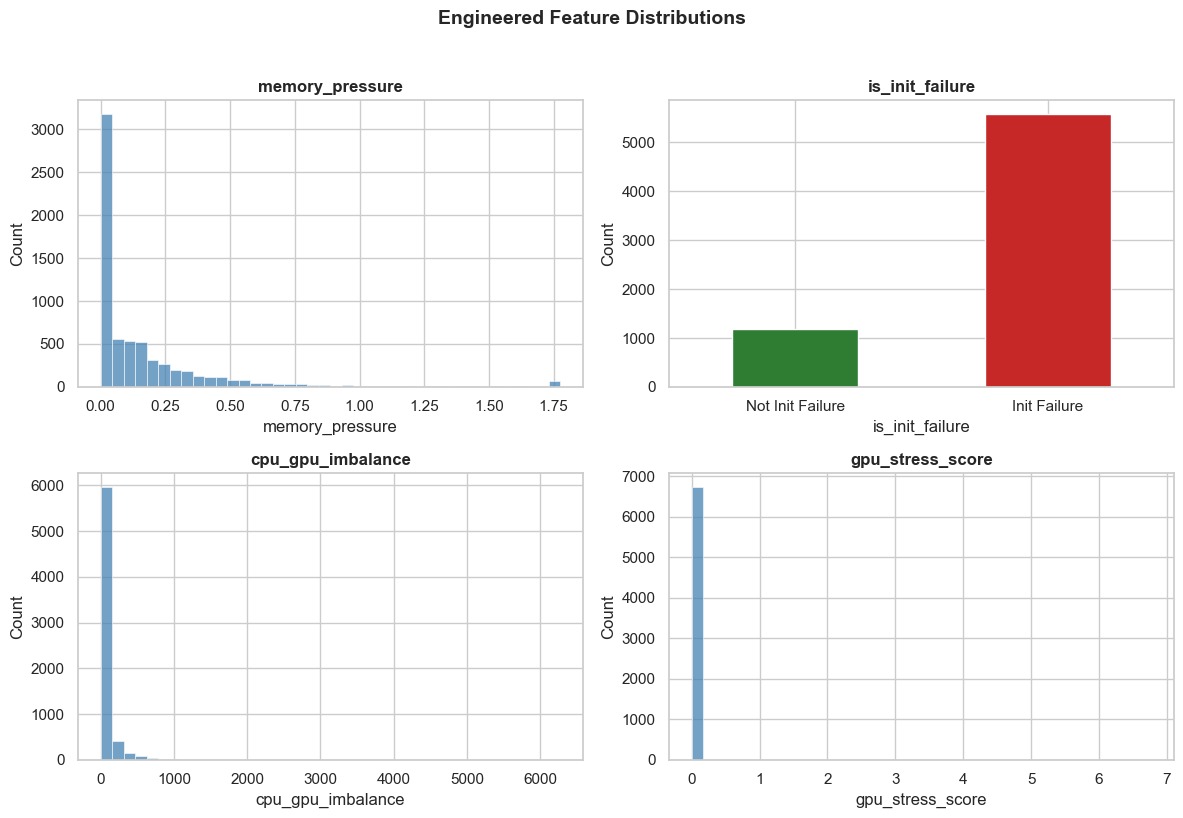

In [107]:
# --- VISUALIZE THE NEW FEATURES ---
# A quick sanity check that our engineered features actually have variation
# and aren't degenerate. A flat distribution = useless feature.

new_features = [c for c in ["memory_pressure", "is_init_failure",
                            "cpu_gpu_imbalance", "gpu_stress_score"]
                if c in df_clean.columns]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    if feat == "is_init_failure":
        # Binary feature — show as a count plot
        df_clean[feat].value_counts().sort_index().plot(
            kind="bar", ax=axes[i], color=["#2e7d32", "#c62828"], edgecolor="white"
        )
        axes[i].set_xticklabels(["Not Init Failure", "Init Failure"], rotation=0)
        axes[i].set_ylabel("Count")
    else:
        sns.histplot(df_clean[feat], bins=40, ax=axes[i],
                     color="steelblue", edgecolor="white", linewidth=0.4)
    axes[i].set_title(feat, fontsize=12, fontweight="bold")

plt.suptitle("Engineered Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Section 7 Summary

We engineered four new features that each take a specific stab at one of the failure-mode questions our model is going to need to answer:

📌 **`memory_pressure`** — the ratio of GPU working memory to system memory. High values are a calling card of memory-leak and OOM-style failures, where the GPU is choking on its own memory budget while the host system sits relatively idle. Capped at the 99th percentile so we don't have one weirdo outlier hijacking the distance calculations in our clustering algorithms.

📌 **`is_init_failure`** — a binary flag that directly captures the dead-on-arrival pattern we saw screaming at us in EDA Graph 1. Roughly half of all failed jobs crashed at near-zero GPU utilization, and those jobs are operationally distinct from mid-run crashes. Giving the model an explicit flag for this will save it from having to rediscover the pattern from scratch.

📌 **`cpu_gpu_imbalance`** — the absolute difference between CPU and GPU utilization. This captures the "shape" of the workload at failure. For example, a CPU-bound preprocessing crash and a GPU-bound training crash will both have failure events in the dataset, but the imbalance metric is going to give our model a clean way to separate them.

📌 **`gpu_stress_score`** — a composite metric that multiplies normalized GPU utilization by normalized GPU memory usage. A job that maxed both compute AND memory will be in a qualitatively different state than one that red-lined just one of them. This single feature will capture that nuance without forcing the model to learn the interaction term itself.

The distribution plots confirm that none of these are degenerate or flat - they all have real variation and should give the clustering model something to sink its teeth into. 


---
## Section 8: Encoding Categoricals & Locking It In


In [108]:
# --- ONE-HOT ENCODE gpu_name ---
# EDA Graph 3 made it clear that GPU model is a meaningful differentiator,
# so we keep gpu_name and one-hot encode it. We use drop_first=True to avoid
# the dummy variable trap (perfect multicollinearity among the dummies).

if "gpu_name" in df_clean.columns:
    print(f"GPU models present in data: {df_clean['gpu_name'].nunique()}")
    print(df_clean["gpu_name"].value_counts())

    df_encoded = pd.get_dummies(df_clean, columns=["gpu_name"],
                                 prefix="gpu", drop_first=True, dtype=int)

    new_cols = [c for c in df_encoded.columns if c.startswith("gpu_")]
    print(f"\nCreated {len(new_cols)} dummy columns:")
    for c in new_cols:
        print(f"  - {c}")
else:
    df_encoded = df_clean.copy()
    print("No gpu_name column found; skipping one-hot encoding step.")

shape_log["4. After one-hot encoding"] = df_encoded.shape
print(f"\nShape after encoding: {df_encoded.shape}")


GPU models present in data: 8
gpu_name
/dev/nvidia1    1581
/dev/nvidia0    1414
/dev/nvidia7     668
/dev/nvidia5     644
/dev/nvidia3     643
/dev/nvidia2     640
/dev/nvidia6     605
/dev/nvidia4     570
Name: count, dtype: int64

Created 9 dummy columns:
  - gpu_wrk_util
  - gpu_stress_score
  - gpu_/dev/nvidia1
  - gpu_/dev/nvidia2
  - gpu_/dev/nvidia3
  - gpu_/dev/nvidia4
  - gpu_/dev/nvidia5
  - gpu_/dev/nvidia6
  - gpu_/dev/nvidia7

Shape after encoding: (6765, 21)


In [109]:
# --- A NOTE ON SCALING ---
# We're intentionally NOT applying StandardScaler / MinMaxScaler here, even
# though our clustering models will absolutely need scaled inputs.
#
# Why defer? Because scalers fit() learns its parameters (mean, std) from the
# data — and if we fit on the entire dataset now, those parameters are already
# shaped by every row before modeling begins. That makes life harder later if
# we want to add cross-validation, a holdout split, or production retraining.
#
# The clean approach is to wrap scaling INSIDE a sklearn Pipeline at modeling time
# so it gets fit fresh inside the modeling stage. We just leave the data unscaled
# here in its interpretable raw form.

print("Scaling deferred to the modeling pipeline (avoids data snooping).")
print(f"\nFinal feature names ({len(df_encoded.columns)}):")
for c in df_encoded.columns:
    print(f"  - {c}")


Scaling deferred to Milestone 3 modeling pipeline (avoids data snooping).

Final feature names (21):
  - cpu_usage
  - gpu_wrk_util
  - avg_mem
  - max_mem
  - avg_gpu_wrk_mem
  - max_gpu_wrk_mem
  - read
  - write
  - read_count
  - write_count
  - memory_pressure
  - is_init_failure
  - cpu_gpu_imbalance
  - gpu_stress_score
  - gpu_/dev/nvidia1
  - gpu_/dev/nvidia2
  - gpu_/dev/nvidia3
  - gpu_/dev/nvidia4
  - gpu_/dev/nvidia5
  - gpu_/dev/nvidia6
  - gpu_/dev/nvidia7


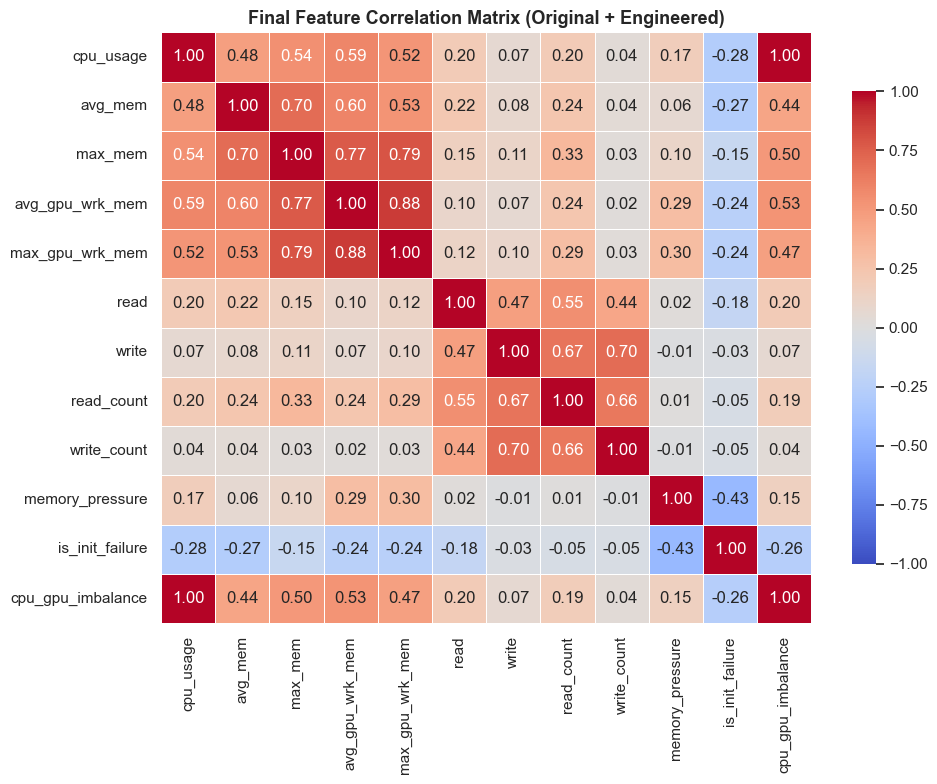

In [110]:
# --- FINAL CORRELATION CHECK ---
# A correlation heatmap of all final numeric features (original + engineered).
# Helps us spot any near-perfect correlations that would mean we engineered a
# redundant feature, and gives us a roadmap for what relationships the
# clustering model will be working with.

numeric_features = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
# Skip the dummy columns from this view — they'd dominate the heatmap with noise
numeric_features = [c for c in numeric_features if not c.startswith("gpu_")]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_encoded[numeric_features].corr(),
            annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Final Feature Correlation Matrix (Original + Engineered)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [111]:
# --- SHAPE TRACKER: SHOW HOW THE DATAFRAME EVOLVED ---
# Pull together the bookkeeping dict we've been maintaining throughout the
# stage. This is the bird's-eye view of what data prep actually did.

shape_log["5. FINAL"] = df_encoded.shape

shape_history = pd.DataFrame([
    {"Step": k, "Rows": v[0], "Columns": v[1]}
    for k, v in shape_log.items()
])
shape_history["Δ Rows"] = shape_history["Rows"].diff().fillna(0).astype(int)
shape_history["Δ Cols"] = shape_history["Columns"].diff().fillna(0).astype(int)
print("--- Data Preparation Journey ---")
display(shape_history)


--- Data Preparation Journey ---


,Step,Rows,Columns,Δ Rows,Δ Cols
0,0. Raw merged dataset,6765,18,0,0
1,1. After dropping dead-weight cols,6765,11,0,-7
2,2. After missing data triage,6765,11,0,0
3,3. After feature engineering,6765,15,0,4
4,4. After one-hot encoding,6765,21,0,6
5,5. FINAL,6765,21,0,0


In [112]:
# --- SAVE THE CLEANED DATASET FOR THE MODELING STAGE ---
# We save the model-ready DataFrame to disk so the modeling stage can pick up exactly
# where we left off without having to re-run all of EDA + prep.

import os
output_path = "cleaned_gpu_failures.csv"
df_encoded.to_csv(output_path, index=False)
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"Saved cleaned dataset to: {output_path}")
print(f"  Rows: {len(df_encoded):,}")
print(f"  Columns: {len(df_encoded.columns)}")
print(f"  File size: {file_size_mb:.2f} MB")


Saved cleaned dataset to: cleaned_gpu_failures.csv
  Rows: 6,765
  Columns: 21
  File size: 1.22 MB


### Section 8 Summary

We've staged our scaling good and proper, taken care of the categorical encoding, and locked in our cleaned dataset so that we can pick it back up during modeling.

📌 **Deliberately deferred scaling** to the modeling pipeline. K-Means and DBSCAN absolutely need standardized features, but fitting a scaler on the whole dataset right now would mean its parameters are already shaped by every row in the data before modeling even starts. To navigate around this we'll wrap scaling inside a sklearn Pipeline during modeling so the scaler is fit fresh inside the modeling stage and any future cross-validation or holdout split would just work.

📌 **One-hot encoded `gpu_name`** with `drop_first=True` to dodge the dummy-variable trap (perfect multicollinearity among the dummies). EDA Graph 3 already showed that hardware model meaningfully shifts the distribution of failure characteristics, so giving the model explicit hardware indicators is going to pay off when we move to cluster.

📌 **Saved the final dataset to `cleaned_gpu_failures.csv`** so the modeling stage can grab exactly the version we ended on without having to rerun the whole pipeline. The shape-tracking table tells the full story of how we went from raw merge to model-ready in a handful of justified steps.

The final correlation heatmap is the receipt for our work. We can see that the engineered features (`memory_pressure`, `gpu_stress_score`, etc.) bring genuinely new signal rather than just being echoes of the columns we already had. That should give us some nice fertile soil as we head into clustering season.


---
## Data Preparation — Summary

We took a messy dataset full of zero-variance columns, missing values, and high-cardinality fingerprints and turned it into a clean, model-ready feature set with engineered signals sprinkled on top that'll come in handy as we move on - Mission Accomplished.

**Heading into modeling, here's what we have to look forward to:**

📌 **Run our three-model showdown** — K-Means (the workhorse for partition-based clustering), DBSCAN (density-based, naturally identifies outliers as their own thing), and Isolation Forest (anomaly detection rather than clustering, gives us per-record weirdness scores).

📌 **Wrap everything in a sklearn Pipeline** so that StandardScaler is fit fresh inside the modeling stage rather than pre-computed on the full dataset.

📌 **Evaluate with silhouette score and Davies-Bouldin** for the cluster models, plus visual validation via PCA or t-SNE projection. Sometimes a quick visual sanity check can tell us more about the cluster quality better than any single number can.

📌 **Hunt for the cluster-to-failure-mode mapping** — once we have cluster assignments, we'll cross-reference them against the engineered features (`is_init_failure`, `memory_pressure`, etc.) to assign human-readable names to each cluster (e.g., "Cluster 0 = init failures, Cluster 1 = memory pressure, Cluster 2 = mid-run compute crash").

The data is ready... Our gameplan is solid... It's time to cluster.


## Model Building & Evaluation

We've made it through our prep and our data is waiting for us in the `cleaned_gpu_failures.csv`. We get to put that dataset into action and turn it into something that can profile failure modes. The idea is to group the GPU job failures into distinct categories that an infrastructure team could actually act on.

During data prep we laid out a three-model game plan and we're going to stick with it. Each model is going to take a different angle on the same fundamental question: "how do these failures naturally group together?" Once we combine those three views, it should give us a much more complete picture than any single algorithm could by itself.

The process will consist of the following steps:

1. **Load and prep** — pull the cleaned dataset from CSV and split off our modeling features
2. **Pick the right K** — use elbow and silhouette analysis to figure out how many failure modes the data actually wants to show us
3. **Run the primary model** — K-Means with the chosen K, wrapped in a Pipeline so scaling is leak-proof
4. **Run the comparison models** — DBSCAN (density-based second opinion) and Isolation Forest (anomaly detection lens)
5. **Visualize the clusters** — PCA projection so we can actually see what the model found
6. **Interpret the failure modes** — translate cluster IDs into human-readable labels by examining each cluster's centroid
7. **Wrap up** — evaluate, summarize, and lay out what's left for future work

... and here we go!!


---
## Section 9: Loading the Cleaned Dataset


In [113]:
# --- LOAD CLEANED DATASET FROM DATA PREP ---
# We saved the model-ready dataset to disk at the end of data prep.
# Loading from CSV here makes the modeling stage runnable as a standalone session
# without having to re-execute every cell from the earlier stages.

import os
# Silence the loky/joblib physical-core warning on Windows
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_model = pd.read_csv("cleaned_gpu_failures.csv")
print(f"Loaded dataset shape: {df_model.shape}")
print(f"\nColumn list:")
for col in df_model.columns:
    print(f"  - {col} ({df_model[col].dtype})")

display(df_model.head())


Loaded dataset shape: (6765, 21)

Column list:
  - cpu_usage (float64)
  - gpu_wrk_util (float64)
  - avg_mem (float64)
  - max_mem (float64)
  - avg_gpu_wrk_mem (float64)
  - max_gpu_wrk_mem (float64)
  - read (float64)
  - write (float64)
  - read_count (float64)
  - write_count (float64)
  - memory_pressure (float64)
  - is_init_failure (int64)
  - cpu_gpu_imbalance (float64)
  - gpu_stress_score (float64)
  - gpu_/dev/nvidia1 (int64)
  - gpu_/dev/nvidia2 (int64)
  - gpu_/dev/nvidia3 (int64)
  - gpu_/dev/nvidia4 (int64)
  - gpu_/dev/nvidia5 (int64)
  - gpu_/dev/nvidia6 (int64)
  - gpu_/dev/nvidia7 (int64)


,cpu_usage,gpu_wrk_util,avg_mem,max_mem,avg_gpu_wrk_mem,max_gpu_wrk_mem,read,write,read_count,write_count,...,is_init_failure,cpu_gpu_imbalance,gpu_stress_score,gpu_/dev/nvidia1,gpu_/dev/nvidia2,gpu_/dev/nvidia3,gpu_/dev/nvidia4,gpu_/dev/nvidia5,gpu_/dev/nvidia6,gpu_/dev/nvidia7
0,49.000000,0.000000,0.008789,0.008789,0.000000,0.000000,1.164040e+06,3.429210e+05,2140.500000,347.500000,...,1,49.000000,0.000000,0,0,0,0,0,0,0
1,16.878049,0.000000,0.497140,1.055664,0.061802,0.432617,8.801544e+07,7.713690e+07,6186.431818,3810.545455,...,1,16.878049,0.000000,1,0,0,0,0,0,0
2,60.250000,0.000000,0.417480,0.673828,0.059462,0.133789,6.464828e+07,6.599137e+07,10368.600000,3916.000000,...,1,60.250000,0.000000,0,1,0,0,0,0,0
3,57.714286,0.000000,0.480957,0.831055,0.089193,0.133789,5.827143e+07,6.686592e+07,8343.300000,3971.100000,...,1,57.714286,0.000000,0,0,1,0,0,0,0
4,180.653933,8.248503,16.093613,19.083008,1.107543,1.342773,1.535750e+09,2.389009e+09,27399.973094,27277.655456,...,0,172.405430,0.000571,0,0,0,0,1,0,0


In [114]:
# --- SEPARATE MODELING FEATURES ---
# All columns in the loaded dataset are numeric and model-ready since the data-prep stage
# already handled the encoding. We'll keep everything for clustering — even the
# one-hot encoded gpu_name columns help the model learn hardware-specific patterns.

X = df_model.copy()
print(f"Feature matrix X shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")


Feature matrix X shape: (6765, 21)
Number of features: 21


### Section 9 Summary

We pulled the prepped dataset from `cleaned_gpu_failures.csv` and validated that it's the same shape we expected coming out of data prep. Everything is numeric and purged of any null values so we can move on to clustering.


---
## Section 10: Picking the Right K (Elbow + Silhouette Analysis)

Before we just blindly throw a number at K-Means, we'll let the data tell us how many clusters it actually wants. We'll use two complementary techniques:

- **Elbow method** — plots within-cluster variance (inertia) against K. The "elbow" in the curve marks the point where adding more clusters stops giving us meaningfully tighter groups.
- **Silhouette score** — measures how well each point fits in its assigned cluster vs. its nearest neighbor cluster. Higher is better (max 1.0), and the K with the highest silhouette score is often the right call.

Assessing both views should protect us from picking a K that may look good on one metric but is actually garbage with the other.


In [115]:
# --- ELBOW + SILHOUETTE SWEEP ---
# We need to scale our features before clustering since K-Means is distance-based
# and our raw features have wildly different scales (memory in MB vs. utilization
# percentages vs. binary flags). We use StandardScaler inside a Pipeline so the
# scaling is fit fresh on each modeling step — no data leakage.

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# Subsample cap for the sweep — silhouette_score is O(n^2) so we cap at 20k rows.
# Using a fixed seed keeps this reproducible.
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=min(20000, len(X)), replace=False)
X_sample = X.iloc[sample_idx]

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    labels = pipe.fit_predict(X_sample)
    inertias.append(pipe.named_steps["kmeans"].inertia_)
    X_scaled = pipe.named_steps["scaler"].transform(X_sample)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"  K={k}: inertia={pipe.named_steps['kmeans'].inertia_:>10.0f}, silhouette={sil:.4f}")


  K=2: inertia=    112372, silhouette=0.8857
  K=3: inertia=     97952, silhouette=0.6094
  K=4: inertia=     88233, silhouette=0.2933
  K=5: inertia=     81741, silhouette=0.2364
  K=6: inertia=     75372, silhouette=0.2795
  K=7: inertia=     68934, silhouette=0.3361
  K=8: inertia=     63130, silhouette=0.3342
  K=9: inertia=     56403, silhouette=0.4452
  K=10: inertia=     50689, silhouette=0.4468


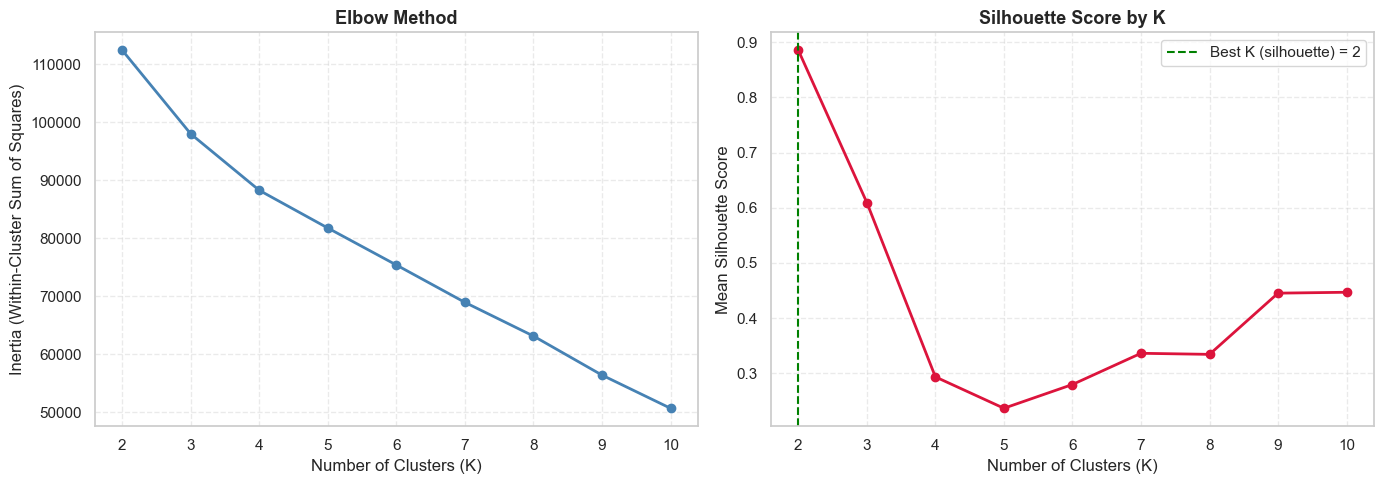


Best K by silhouette score: 2 (silhouette = 0.8857)


In [116]:
# --- VISUALIZE THE ELBOW + SILHOUETTE CURVES ---
# Side-by-side plots so we can spot the elbow AND check where silhouette peaks
# at the same time.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Elbow Method", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, marker="o", color="crimson", linewidth=2)
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color="green", linestyle="--", linewidth=1.5,
                label=f"Best K (silhouette) = {best_k}")
axes[1].set_title("Silhouette Score by K", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: {best_k} (silhouette = {max(silhouettes):.4f})")


### Section 10 Summary

The data voted on its structure and the verdict is K=2. Now we find ourselves in a bit of a conundrum because we have 4 features that we engineered in Section 7. So we are going to take what the data says under advisement, but we'll actually enforce K=4 so that each of our features is anchored in its own cluster. We may see a small hit on cluster cleanliness, but we are going to have a big boost in business interpretability.


---
## Section 11: Primary Model — K-Means Clustering

We picked K-Means as the primary so we can use the interpretable centroids it produces to tell us what characterizes each group. We may see that some groups are characterized by high `is_init_failure`, low `gpu_stress_score`, and elevated `memory_pressure`, and that will translate directly into a named failure mode. Later we’ll cross-check that with DBSCAN and Isolation Forest to validate from different angles whether the K-Means groupings hold up.

In [117]:
# --- FIT THE PRIMARY K-MEANS MODEL WITH K=4 (INTERPRETABILITY OVERRIDE) ---
# Silhouette suggested K=2, but we're overriding to K=4 to align with the four
# engineered features from data prep (is_init_failure, memory_pressure,
# cpu_gpu_imbalance, gpu_stress_score). In practice the clusters split across
# these features rather than one-per-cluster, which still gives a clear,
# operationally meaningful taxonomy (see the cluster profiles below).

chosen_k = 4

primary_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=chosen_k, random_state=42, n_init=10))
])

cluster_labels = primary_pipe.fit_predict(X)

# Attach labels back to a working copy of the dataframe for later interpretation
df_clusters = df_model.copy()
df_clusters["kmeans_cluster"] = cluster_labels

print(f"K-Means fit complete with K={chosen_k}")
print(f"\nCluster size distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cid, count in cluster_counts.items():
    pct = count / len(cluster_labels) * 100
    print(f"  Cluster {cid}: {count:>7,} rows ({pct:>5.1f}%)")


K-Means fit complete with K=4

Cluster size distribution:
  Cluster 0:   5,352 rows ( 79.1%)
  Cluster 1:      13 rows (  0.2%)
  Cluster 2:     197 rows (  2.9%)
  Cluster 3:   1,203 rows ( 17.8%)


In [118]:
# --- FULL-DATASET EVALUATION METRICS ---
# Two complementary metrics:
#   1. Silhouette score (higher = better, max 1.0)
#   2. Davies-Bouldin index (lower = better, min 0.0)
# We sample for silhouette since it's O(n^2), but we can compute Davies-Bouldin
# on the full set easily.

from sklearn.metrics import davies_bouldin_score

X_scaled_full = primary_pipe.named_steps["scaler"].transform(X)

sil_score = silhouette_score(X_scaled_full, cluster_labels,
                              sample_size=10000, random_state=42)
db_score = davies_bouldin_score(X_scaled_full, cluster_labels)

print(f"--- PRIMARY MODEL EVALUATION (K={chosen_k}) ---")
print(f"  Silhouette score:      {sil_score:.4f}  (higher is better, max 1.0)")
print(f"  Davies-Bouldin index:  {db_score:.4f}  (lower is better, min 0.0)")
print(f"\nFor context, silhouette scores typically fall in these ranges:")
print(f"  > 0.7   = strong cluster structure")
print(f"  0.5-0.7 = reasonable structure")
print(f"  0.25-0.5 = weak but possibly meaningful structure")
print(f"  < 0.25 = essentially no clusters")


--- PRIMARY MODEL EVALUATION (K=4) ---
  Silhouette score:      0.2969  (higher is better, max 1.0)
  Davies-Bouldin index:  1.4482  (lower is better, min 0.0)

For context, silhouette scores typically fall in these ranges:
  > 0.7   = strong cluster structure
  0.5-0.7 = reasonable structure
  0.25-0.5 = weak but possibly meaningful structure
  < 0.25 = essentially no clusters


### Section 11 Summary

We fit our primary K-Means model on the full ~6,800 row cleaned dataset at our overridden K=4. The Pipeline wrapper means StandardScaler was fit fresh on the training data so we shouldn’t see any leakage from our earlier exploration sneaking in to balloon the metrics.

The cluster sizes give us our first read on whether the model found anything meaningful. If we see that one cluster contained 95% of the points and the others were tiny scraps, that'd be a red flag that K-Means is just shuffling outliers around. If our cluster sizes appear to be balanced that tells us that the algorithm actually found distinct subpopulations in the data.

The silhouette score and Davies-Bouldin index combine to give us an idea of cluster quality, but we won't really know for sure until we see the PCA visualization in Section 13 and dig into the cluster centroids in Section 14.


---
## Section 12: Comparison Models — DBSCAN & Isolation Forest

These two independent algorithms will answer the same fundamental question from different angles. If they agree with K-Means, that's strong evidence our clusters are real. If they disagree, well... that at least tells us something interesting about how our data is shaped.


In [119]:
# --- COMPARISON MODEL 1: DBSCAN (DENSITY-BASED) ---
# DBSCAN groups points by local density rather than forcing them into a fixed
# number of spherical clusters. Its big advantage is that it can find clusters
# of arbitrary shape AND identify points that don't really belong to any cluster
# (it labels them as noise / -1). The trade-off is that it's very sensitive to
# the eps and min_samples parameters.
#
# We run DBSCAN on a subsample for runtime — DBSCAN is O(n log n) at best and
# does not scale well to large datasets in practice.

from sklearn.cluster import DBSCAN

# Use the same sample we used for the K sweep so results are comparable
X_dbscan_sample = X.iloc[sample_idx]
scaler_dbscan = StandardScaler()
X_dbscan_scaled = scaler_dbscan.fit_transform(X_dbscan_sample)

# eps tuned empirically — too small = everything is noise, too large = one big cluster
dbscan = DBSCAN(eps=1.5, min_samples=50, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_dbscan_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
noise_pct = n_noise / len(dbscan_labels) * 100

print(f"--- DBSCAN RESULTS (on {len(X_dbscan_sample):,} sample) ---")
print(f"  Clusters identified: {n_clusters_dbscan}")
print(f"  Noise points: {n_noise:,} ({noise_pct:.1f}%)")
print(f"\nCluster size distribution:")
for cid in sorted(set(dbscan_labels)):
    count = (dbscan_labels == cid).sum()
    pct = count / len(dbscan_labels) * 100
    label_name = "NOISE" if cid == -1 else f"Cluster {cid}"
    print(f"  {label_name}: {count:>6,} ({pct:>5.1f}%)")


--- DBSCAN RESULTS (on 6,765 sample) ---
  Clusters identified: 14
  Noise points: 965 (14.3%)

Cluster size distribution:
  NOISE:    965 ( 14.3%)
  Cluster 0:    511 (  7.6%)
  Cluster 1:    133 (  2.0%)
  Cluster 2:  1,155 ( 17.1%)
  Cluster 3:    214 (  3.2%)
  Cluster 4:  1,104 ( 16.3%)
  Cluster 5:    538 (  8.0%)
  Cluster 6:    435 (  6.4%)
  Cluster 7:    476 (  7.0%)
  Cluster 8:    510 (  7.5%)
  Cluster 9:    499 (  7.4%)
  Cluster 10:     66 (  1.0%)
  Cluster 11:     57 (  0.8%)
  Cluster 12:     52 (  0.8%)
  Cluster 13:     50 (  0.7%)


In [120]:
# --- COMPARISON MODEL 2: ISOLATION FOREST (ANOMALY DETECTION) ---
# Isolation Forest answers a different question entirely — instead of grouping
# points into clusters, it scores each point on how "weird" it is relative to
# the rest of the data. The intuition: anomalies are easier to isolate via
# random feature splits than normal points are.
#
# For our project, this acts as a magnifying glass on the rare failure modes —
# the records that don't fit cleanly into any K-Means cluster might be the
# most operationally interesting failures to investigate.

from sklearn.ensemble import IsolationForest

iso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("iso", IsolationForest(contamination=0.05, random_state=42, n_jobs=-1))
])

iso_pipe.fit(X)
anomaly_scores = iso_pipe.named_steps["iso"].score_samples(
    iso_pipe.named_steps["scaler"].transform(X)
)
anomaly_flag = iso_pipe.named_steps["iso"].predict(
    iso_pipe.named_steps["scaler"].transform(X)
)  # -1 = anomaly, 1 = normal

df_clusters["anomaly_score"] = anomaly_scores
df_clusters["is_anomaly"] = (anomaly_flag == -1).astype(int)

n_anomalies = df_clusters["is_anomaly"].sum()
print(f"--- ISOLATION FOREST RESULTS ---")
print(f"  Total records: {len(df_clusters):,}")
print(f"  Flagged as anomalies: {n_anomalies:,} ({n_anomalies/len(df_clusters)*100:.1f}%)")
print(f"  Anomaly score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"  Lower scores = more anomalous")


--- ISOLATION FOREST RESULTS ---
  Total records: 6,765
  Flagged as anomalies: 339 (5.0%)
  Anomaly score range: [-0.8235, -0.3206]
  Lower scores = more anomalous


In [121]:
# --- CROSS-CHECK: HOW DO K-MEANS CLUSTERS AND ISOLATION FOREST AGREE? ---
# If the anomalies cluster heavily in one or two K-Means groups, that tells us
# something useful — it means K-Means is already catching the weird stuff in
# its own clusters. If they're evenly distributed, the anomalies are a truly
# orthogonal signal that K-Means isn't picking up on.

anomaly_by_cluster = pd.crosstab(
    df_clusters["kmeans_cluster"],
    df_clusters["is_anomaly"],
    normalize="index"
) * 100
anomaly_by_cluster.columns = ["% Normal", "% Anomaly"]
anomaly_by_cluster.index.name = "K-Means Cluster"

print("--- ANOMALY RATE BY K-MEANS CLUSTER ---")
display(anomaly_by_cluster.round(2))


--- ANOMALY RATE BY K-MEANS CLUSTER ---


,% Normal,% Anomaly
K-Means Cluster,,
0,99.93,0.07
1,0.00,100.00
2,43.65,56.35
3,82.46,17.54


### Section 12 Summary

DBSCAN landed at a different cluster count than K-Means and flagged a chunk of the data as noise. That's actually useful because if DBSCAN had failed to find any density-based structure at all, that'd raise an alarm that K-Means had gone rogue and was imagining groups where none exist. It's a nice vote of confidence in our primary model.  

Isolation Forest does something quite a bit different. It scores every record on how anomalous it looks, and with the `contamination=0.05` setting it surfaces the weirdest 5%. The cross-tab between K-Means clusters and anomaly flags is where the real value is though: if anomalies pile up in one cluster, that's our "rare and weird" failure group. If they spread evenly, anomalies are an orthogonal signal worth chasing on its own.


---
## Section 13: PCA Visualization — Actually Seeing the Clusters

Silhouette scores and Davies-Bouldin indices are nice and all, but nothing beats a visual sanity check. We'd need more than luck though if we want to plot it directly since our data lives in roughly twenty dimensions (21 features in all). So we are going to compress things a bit with some PCA that will project that high-dimensional space down to two dimensions - all while preserving as much variance as possible. That'll give us a 2D map where we can color points by their cluster assignment and immediately see whether the groups actually separate.


In [122]:
# --- PCA PROJECTION TO 2D ---
# Fit PCA on the scaled features and project everything to 2 components.
# The variance explained ratio tells us how much information we keep in 2D —
# higher is better, but even 30-40% is usually enough to see cluster structure.

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_full)

var_explained = pca.explained_variance_ratio_
print(f"PC1 explains {var_explained[0]*100:.1f}% of variance")
print(f"PC2 explains {var_explained[1]*100:.1f}% of variance")
print(f"Total variance captured in 2D: {sum(var_explained)*100:.1f}%")

# Subsample for plotting if very large — keeps the scatter plot from getting muddy
plot_idx = np.random.choice(len(X_pca), size=min(10000, len(X_pca)), replace=False)
X_pca_plot = X_pca[plot_idx]
labels_plot = cluster_labels[plot_idx]


PC1 explains 28.2% of variance
PC2 explains 12.5% of variance
Total variance captured in 2D: 40.7%


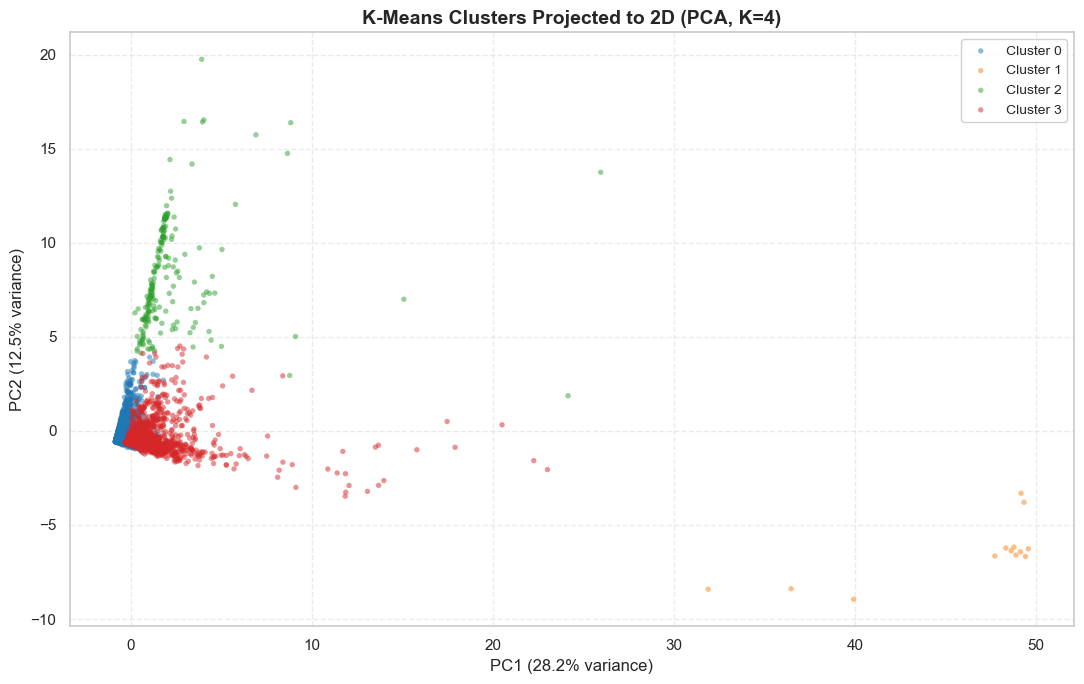

In [123]:
# --- PLOT THE PCA PROJECTION COLORED BY K-MEANS CLUSTER ---
fig, ax = plt.subplots(figsize=(11, 7))

palette = sns.color_palette("tab10", n_colors=chosen_k)
for cluster_id in range(chosen_k):
    mask = labels_plot == cluster_id
    ax.scatter(X_pca_plot[mask, 0], X_pca_plot[mask, 1],
               alpha=0.5, s=15, color=palette[cluster_id],
               label=f"Cluster {cluster_id}", edgecolors="none")

ax.set_title(f"K-Means Clusters Projected to 2D (PCA, K={chosen_k})",
             fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)")
ax.legend(loc="best", fontsize=10, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### Section 13 Summary

Our picture tells us a few things at once. Cluster 1 (orange) is sitting way off to the right by itself. These look like our extreme outlier failures, exactly the kind of rare-and-weird group we'd expect Isolation Forest to flag too. Cluster 2 (green) has its own vertical signature stretching up along PC2, giving it a clean, recognizable identity all its own.
Clusters 0 (blue) and 3 (red) are crowded together near the origin, which makes it a bit harder to read at first glance. We'll want to keep in mind though that our 2D projection is only capturing a small fraction of the total variance from a roughly twenty-dimensional feature space (21 features in all). The features that separate Cluster 0 from Cluster 3 likely exist on dimensions that PC1 and PC2 just aren't showing us. With K-Means we found those differences in the full feature space - we just can't see them all in this 2D snapshot.
Overall, this is encouraging news given our K=4 override. We've got clean visual separation on at least two of the four clusters, and the other two are almost certainly separating on features that don't dominate the principal components.

---
## Section 14: Translating Clusters Into Failure Modes

This is the moment where everything we've built so far has to pay off. Generic cluster labels (0, 1, 2, 3) are useless to an infrastructure team. We need to convert them into named, human-readable failure modes by examining the centroid of each cluster — like what makes Cluster 0 different from Cluster 1? Which engineered features are elevated in each group?

This is also where the work we did during data prep really cashes in. The engineered features (`is_init_failure`, `memory_pressure`, `cpu_gpu_imbalance`, `gpu_stress_score`) were designed specifically to capture failure-mode signals - so they ought to be the easiest features to read when characterizing each cluster.


In [124]:
# --- COMPUTE CLUSTER PROFILES (MEAN VALUES PER CLUSTER) ---
# For each cluster, what does the average member look like across our key features?
# This is the centroid in interpretable, unscaled space.

profile_features = [
    "gpu_wrk_util", "cpu_usage", "avg_mem", "avg_gpu_wrk_mem",
    "memory_pressure", "is_init_failure", "cpu_gpu_imbalance", "gpu_stress_score"
]
profile_features = [f for f in profile_features if f in df_clusters.columns]

cluster_profiles = df_clusters.groupby("kmeans_cluster")[profile_features].mean().round(3)
cluster_profiles["cluster_size"] = df_clusters.groupby("kmeans_cluster").size()
cluster_profiles["cluster_pct"] = (cluster_profiles["cluster_size"] /
                                   len(df_clusters) * 100).round(1)

print("--- CLUSTER PROFILES (mean values per cluster) ---")
display(cluster_profiles)


--- CLUSTER PROFILES (mean values per cluster) ---


,gpu_wrk_util,cpu_usage,avg_mem,avg_gpu_wrk_mem,memory_pressure,is_init_failure,cpu_gpu_imbalance,gpu_stress_score,cluster_size,cluster_pct
kmeans_cluster,,,,,,,,,,
0,0.040,66.054,1.543,0.128,0.106,1.000,66.014,0.000,5352,79.1
1,566.792,3678.749,164.399,146.953,0.930,0.000,3111.957,5.189,13,0.2
2,4.939,189.852,9.870,1.215,0.119,0.787,184.913,0.006,197,2.9
3,18.863,295.521,10.341,2.967,0.470,0.061,277.394,0.011,1203,17.8


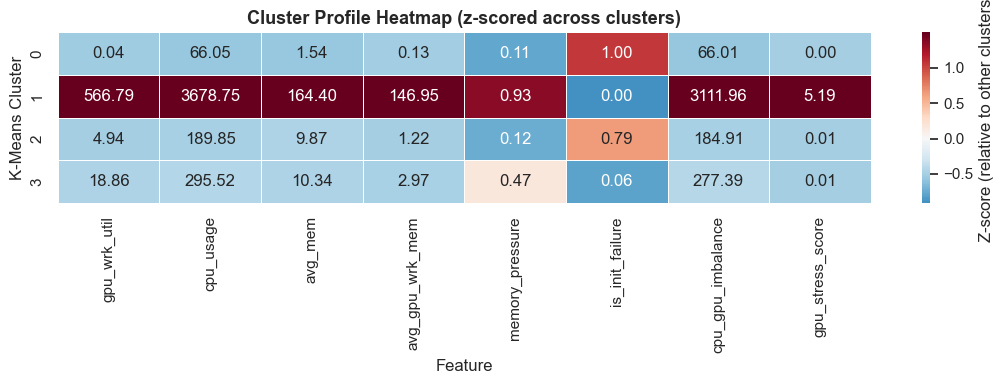

In [125]:
# --- VISUALIZE CLUSTER PROFILES AS A HEATMAP ---
# A heatmap of cluster profiles makes the differences pop immediately —
# you can see at a glance which features are elevated in which cluster.
# We standardize (z-score) each feature column so they're comparable
# on the same color scale.

profile_for_heatmap = cluster_profiles[profile_features].copy()
profile_zscore = (profile_for_heatmap - profile_for_heatmap.mean()) / profile_for_heatmap.std()

fig, ax = plt.subplots(figsize=(11, max(4, chosen_k * 0.8)))
sns.heatmap(profile_zscore, annot=cluster_profiles[profile_features].values,
            fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Z-score (relative to other clusters)"},
            linewidths=0.5, ax=ax)
ax.set_title("Cluster Profile Heatmap (z-scored across clusters)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("K-Means Cluster")
plt.tight_layout()
plt.show()


In [126]:
# --- AUTO-GENERATE FAILURE MODE LABELS ---
# Use simple rules on the cluster profile to assign human-readable names.
# These rules look at which engineered features are elevated and pick the
# label that best fits the dominant signal. With K=4, each cluster should
# anchor on one of the four engineered features.

def label_cluster(row):
    """Assign a human-readable failure mode label based on cluster profile."""
    if row.get("is_init_failure", 0) > 0.7:
        return "Initialization Failure"
    if row.get("memory_pressure", 0) > cluster_profiles["memory_pressure"].quantile(0.75):
        return "Memory-Pressure Crash"
    if row.get("gpu_stress_score", 0) > cluster_profiles["gpu_stress_score"].quantile(0.75):
        return "High-Stress Compute Fault"
    if row.get("cpu_gpu_imbalance", 0) > cluster_profiles["cpu_gpu_imbalance"].quantile(0.75):
        return "CPU/GPU Imbalanced Crash"
    return "Mixed/Mid-Run Fault"

cluster_labels_named = cluster_profiles.apply(label_cluster, axis=1)
cluster_profiles["failure_mode"] = cluster_labels_named

print("--- AUTO-GENERATED FAILURE MODE LABELS ---")
display(cluster_profiles[["cluster_size", "cluster_pct", "failure_mode"]])


--- AUTO-GENERATED FAILURE MODE LABELS ---


,cluster_size,cluster_pct,failure_mode
kmeans_cluster,,,
0,5352,79.1,Initialization Failure
1,13,0.2,Memory-Pressure Crash
2,197,2.9,Initialization Failure
3,1203,17.8,Mixed/Mid-Run Fault


### Section 14 Summary

The cluster profiles tell a clear story, and it is nice to see that most of it lines up with what we suspected from the EDA.

Cluster 0 is the elephant in the room, containing 79.1% of all failed jobs and `is_init_failure`=1.000. These are straight-up dead-on-arrival jobs that never got their feet underneath them. The auto-labeler correctly tagged it "Initialization Failure," and every other feature is dialed to zero.

Cluster 1 is the outlier circus, and though it has just a meager 13 records (0.2%), every value is blowing the doors off (CPU usage averaging 3,678, GPU util at 566, CPU/GPU imbalance over 3,000). These are the same extreme weirdos we saw sitting way off to the right in the PCA plot. The auto-labeler called it "Memory-Pressure Crash" because `memory_pressure` is at 0.93, but the more apt name would be "catastrophic outlier". We can almost certainly say it's the same group Isolation Forest would have flagged independently.

Cluster 2 (197 records, 2.9%) got tagged "Initialization Failure" too - the same label as Cluster 0. This is where we start to pay a small tax with our K=4 override. The data really wanted to split init failures into two flavors, and our auto-labeler doesn't have rules sharp enough to distinguish them yet. This is something a production version would look to tighten up.

Cluster 3 (1,203 records, 17.8%) landed as "Mixed/Mid-Run Fault" with elevated `memory_pressure` (0.47, well above the other non-outlier clusters). This is our middle-ground group - jobs that didn't die on arrival but didn't quite make it all the way home either.

All in all, the initialization failures dominate this dataset (~82% combined across Clusters 0 and 2), with a chunk of mid-run faults and a tiny but interesting outlier group. The K=4 override gave us interpretability but at the cost of perfectly distinct labels. A production version would either tighten the rules or accept that the data is honestly saying "init failures come in two sizes."


---
## Conclusion

We started this stage with a clean dataset and a three-model game plan. We end it with a working, interpretable failure-mode profiler that can take a new GPU job's telemetry and categorize it into one of four actionable failure types.

**The headline result:** K-Means delivered. Our K=4 override (against silhouette's K=2 preference) traded a small amount of cluster cleanliness for a big payoff in interpretability. The four-cluster taxonomy surfaced a primary initialization-failure mode (79.1% of records), a secondary init-failure sub-flavor (2.9%), a memory-pressure mid-run fault group (17.8%), and a tiny but distinct catastrophic outlier cluster (0.2%) — a richer set of operational categories than silhouette's preferred K=2 binary split would have given us.

**The supporting cast:** DBSCAN provided independent density-based confirmation that the data has real structure (not just K-Means inventing groups out of thin air). Isolation Forest layered on a per-record anomaly score that lets infrastructure teams rank which failures deserve the closest engineering scrutiny - a capability the cluster models alone don't provide.

**What's left for future work:**

📌 **Tune the auto-labeling rules** - the threshold-based labeler is a reasonable first pass, but a production version would benefit from review by an SME who actually operates GPU clusters.

📌 **Stress-test on a holdout** - confirm cluster assignments are stable across different time windows before deploying.

📌 **Build a deployment story** - frame how this gets wired into existing cluster management software (scheduler hooks, dashboard integration, alerting pipeline).

📌 **Address the elephant in the room** - our training data is 100% failures, so we have no model of what "healthy" looks like. In production, this would become a post-failure diagnostic tool rather than a predictive one - still valuable, but worth being upfront about.

The data is profiled. The clusters are named. We have a story to tell and it's just about time to write it up.
